In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ee_inv = pd.read_csv("../data/processed/ee_invitations_cleaned.csv")
ee_inv.head()

,EN_YEAR,EN_PROVINCE_TERRITORY,EN_INVITATION_CATEGORY,TOTAL
0,2015,Alberta,Canadian Experience Class,4635.0
1,2015,Alberta,Federal Skilled Trades,1385.0
2,2015,Alberta,Federal Skilled Worker,1970.0
3,2015,British Columbia,Canadian Experience Class,1295.0
4,2015,British Columbia,Federal Skilled Trades,200.0


## 1. Invitation trends by category (2015–2026)

How the mix of Express Entry invitations (CEC / FSW / FST / PNP) shifted over time.

**Finding:** CEC dominated throughout (peaking at ~85k ITAs in 2021), but PNP overtook it by 2024 — a structural shift toward province-driven selection. The 2022 collapse reflects IRCC's pause of general draws to clear the COVID backlog.

In [3]:
trend = ee_inv.groupby(["EN_YEAR", "EN_INVITATION_CATEGORY"])["TOTAL"].sum().reset_index()
trend.head(20)

,EN_YEAR,EN_INVITATION_CATEGORY,TOTAL
0,2015,Canadian Experience Class,8045.0
1,2015,Federal Skilled Trades,1845.0
2,2015,Federal Skilled Worker,8665.0
3,2015,Provincial Nominee Program,2980.0
4,2016,Canadian Experience Class,10320.0
5,2016,Federal Skilled Trades,1305.0
6,2016,Federal Skilled Worker,6970.0
7,2016,Provincial Nominee Program,7130.0
8,2017,Canadian Experience Class,29220.0
9,2017,Federal Skilled Trades,340.0


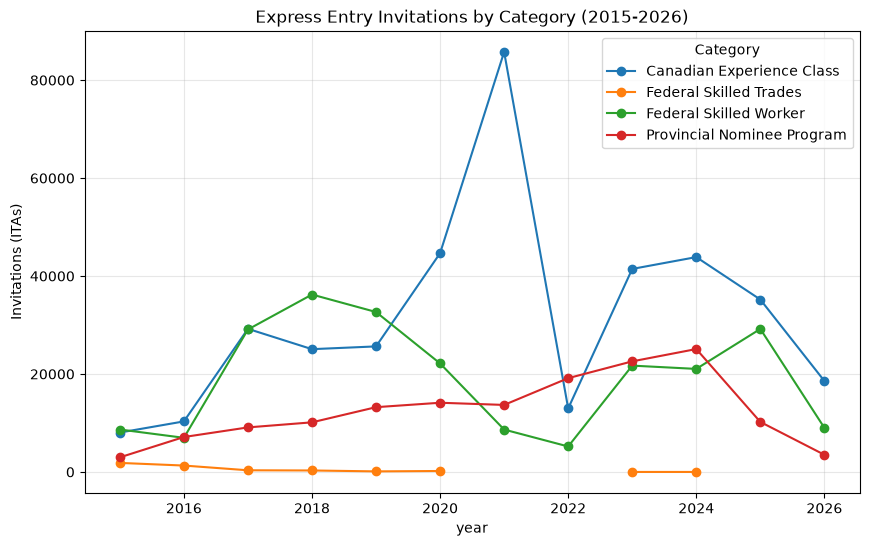

In [4]:
trend_clean = trend[trend['EN_INVITATION_CATEGORY']!='Not Stated']
trend_wide = trend_clean.pivot(index='EN_YEAR',columns='EN_INVITATION_CATEGORY', values='TOTAL')
trend_wide.plot(kind='line',marker='o',figsize=(10,6))
plt.title("Express Entry Invitations by Category (2015-2026)")
plt.xlabel('year')
plt.ylabel("Invitations (ITAs)")
plt.legend(title="Category")
plt.grid(True, alpha=0.3)
plt.show()

## 2a. CRS score distribution over time

Provincial Nominee candidates receive a 600-point CRS bonus, so their scores cluster
at 900+ while regular (CEC/FSW) candidates concentrate at 450–500 — two separate score
regimes that must be analyzed apart. (This is why PNP is excluded from the cutoff trend below.)


In [5]:
ee_score = pd.read_csv("../data/processed/ee_ita_score_cleaned.csv")
print(ee_score["EN_ITA_SCORE"].unique())

<StringArray>
['Score 1001 - 1100',   'Score 401 - 450',   'Score 451 - 500',
   'Score 501 - 600',   'Score 601 - 700',   'Score 701 - 800',
   'Score 801 - 900',  'Score 901 - 1000', 'Score 1101 - 1200',
   'Score 201 - 250',   'Score 251 - 300',   'Score 301 - 350',
   'Score 351 - 400',   'Score 151 - 200',   'Score 101 - 150',
    'Score 51 - 100']
Length: 16, dtype: str


In [6]:
ee_score.groupby("EN_ITA_SCORE")["TOTAL"].sum(min_count=1).sort_values(ascending=False).head(10)

EN_ITA_SCORE
Score 451 - 500      305895.0
Score 501 - 600      137635.0
Score 401 - 450      122305.0
Score 901 - 1000      81405.0
Score 1001 - 1100     66290.0
Score 351 - 400       23500.0
Score 801 - 900       15695.0
Score 701 - 800        6065.0
Score 601 - 700        2395.0
Score 301 - 350        2205.0
Name: TOTAL, dtype: float64

In [7]:
ee_score["score_start"] = ee_score["EN_ITA_SCORE"].str.extract(r"(\d+)").astype(int)
ee_score[["EN_ITA_SCORE", "score_start"]].drop_duplicates().sort_values("score_start")

,EN_ITA_SCORE,score_start
1070,Score 51 - 100,51
1043,Score 101 - 150,101
402,Score 151 - 200,151
391,Score 201 - 250,201
392,Score 251 - 300,251
393,Score 301 - 350,301
394,Score 351 - 400,351
1,Score 401 - 450,401
2,Score 451 - 500,451
3,Score 501 - 600,501


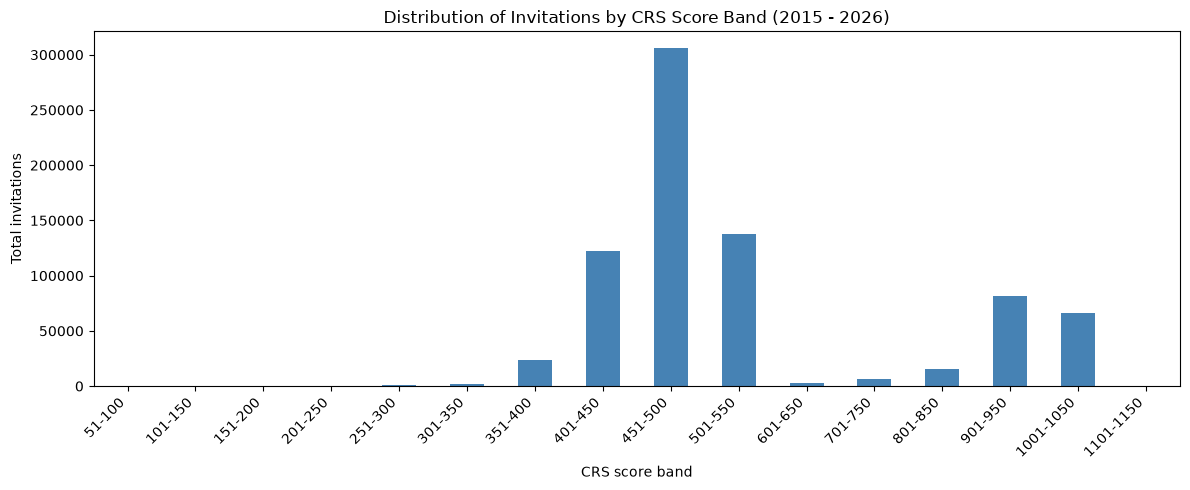

In [8]:
dist = ee_score.groupby("score_start")["TOTAL"].sum(min_count=1).sort_index()
dist.index = [f"{s}-{s+49}" for s in dist.index]

dist.plot(kind="bar", figsize=(12, 5), color="steelblue")
plt.title("Distribution of Invitations by CRS Score Band (2015 - 2026)")
plt.xlabel("CRS score band")
plt.ylabel("Total invitations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 2b. CRS cutoff trend by draw type (2015–2026)

The actual CRS cut-off of each of 427 draws, coloured by draw type.

**Finding:** General draws hold steady around 450–500, while PNP sits far above (700+,inflated by the 600-point bonus). From 2023, category-based draws open a distinct lower tier — IRCC trading raw CRS for targeted occupations and French.


In [9]:
ee_rounds = pd.read_csv('../data/raw/ee_rounds.csv', parse_dates=['draw_date'])
print(ee_rounds.shape)
print(ee_rounds['draw_name'].unique())

(427, 5)
<StringArray>
[                                         'No Program Specified',
                                     'Canadian Experience Class',
                                    'Provincial Nominee Program',
                                        'Federal Skilled Trades',
                                        'Federal Skilled Worker',
                            'Healthcare occupations (Version 1)',
                                  'STEM occupations (Version 1)',
                       'French language proficiency (Version 1)',
                                 'Trade occupations (Version 1)',
                             'Transport occupations (Version 1)',
             'Agriculture and agri-food occupations (Version 1)',
                                                       'General',
                             'Education occupations (Version 1)',
        'Healthcare and social services occupations (Version 2)',
                                 'Trade occupations (

In [10]:
def categorize(name):
    if name in ["No Program Specified", "General"]:
        return "General"
    if name == "Provincial Nominee Program":
        return "PNP"
    if name in ["Canadian Experience Class", "Federal Skilled Worker", "Federal Skilled Trades"]:
        return "Program-specific"
    return "Category-based (CBS)"   # 其余全是 2023 起的类别式邀请

ee_rounds["draw_group"] = ee_rounds["draw_name"].apply(categorize)
print(ee_rounds["draw_group"].value_counts())


draw_group
General                 178
PNP                     108
Program-specific         72
Category-based (CBS)     69
Name: count, dtype: int64


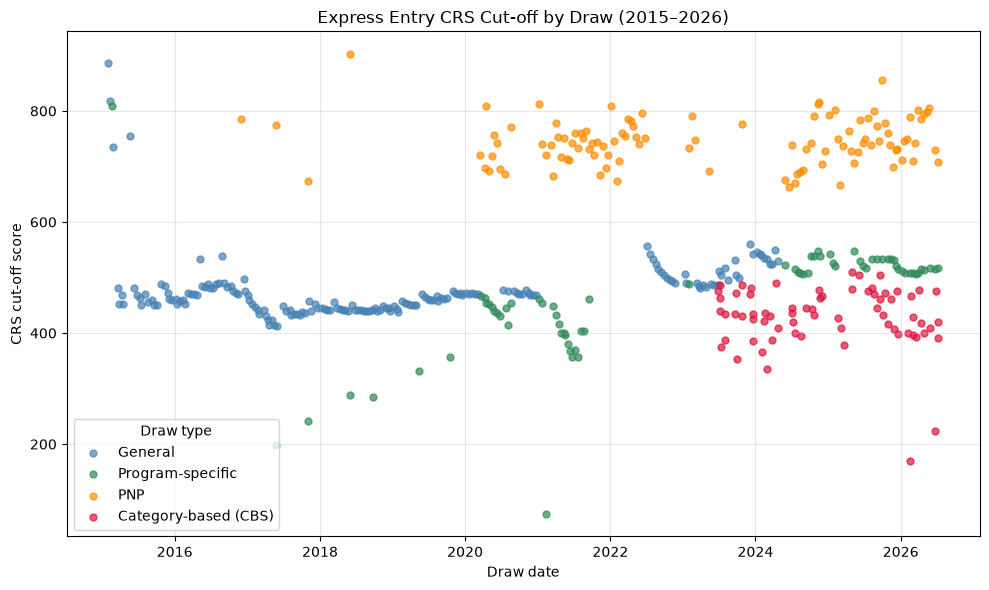

In [11]:
import matplotlib.pyplot as plt

groups = ["General", "Program-specific", "PNP", "Category-based (CBS)"]
colors = {"General": "steelblue", "Program-specific": "seagreen",
          "PNP": "darkorange", "Category-based (CBS)": "crimson"}

plt.figure(figsize=(10, 6))
for g in groups:
    sub = ee_rounds[ee_rounds["draw_group"] == g]
    plt.scatter(sub["draw_date"], sub["crs_cutoff"], label=g,
                color=colors[g], s=25, alpha=0.7)

plt.title("Express Entry CRS Cut-off by Draw (2015–2026)")
plt.xlabel("Draw date")
plt.ylabel("CRS cut-off score")
plt.legend(title="Draw type")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. PR admissions by province (2015–2026)

Which provinces absorbed the most Express Entry immigrants, and how the distribution shifted.

**Finding:** Ontario dominates and its lead widened over time (peaking near 97k in 2021), absorbing roughly half of all Express Entry PR admissions. The 2020 dip reflects pandemic border/processing disruruption, followed by a sharp 2021 rebound. (2026 excluded as an incomplete year.)

In [12]:
pr_cat = pd.read_csv('../data/processed/pr_admissions_by_category_cleaned.csv')
pr_cat.head()

,EN_YEAR,EN_QUARTER,EN_MONTH,EN_PROVINCE_TERRITORY,EN_IMMIGRATION_CATEGORY-COMPONENT,TOTAL,category_standard
0,2025,Q4,Dec,Ontario,Canadian Experience,150.0,Canadian Experience Class
1,2016,Q1,Jan,Alberta,Skilled Trade,275.0,Federal Skilled Trades
2,2025,Q3,Jul,Manitoba,Canadian Experience,35.0,Canadian Experience Class
3,2016,Q3,Sep,Nova Scotia,Provincial Nominee Program,115.0,Provincial Nominee Program
4,2019,Q1,Feb,Alberta,Provincial Nominee Program,10.0,Provincial Nominee Program


In [13]:
pr_cat.groupby("EN_PROVINCE_TERRITORY")["TOTAL"].sum().sort_values(ascending=False)


EN_PROVINCE_TERRITORY
Ontario                      608220.0
British Columbia             194190.0
Alberta                      116420.0
Saskatchewan                  32880.0
Nova Scotia                   30515.0
Manitoba                      29760.0
New Brunswick                 24790.0
Prince Edward Island           5645.0
Newfoundland and Labrador      3035.0
Northwest Territories           440.0
Yukon                           335.0
Nunavut                          35.0
Name: TOTAL, dtype: float64

In [14]:
top3 = ["Ontario", "British Columbia", "Alberta"]

pr_cat["province_group"] = pr_cat["EN_PROVINCE_TERRITORY"].where(
    pr_cat["EN_PROVINCE_TERRITORY"].isin(top3), "Other")

prov_trend = pr_cat.groupby(["EN_YEAR", "province_group"])["TOTAL"].sum().reset_index()
prov_wide = prov_trend.pivot(index="EN_YEAR", columns="province_group", values="TOTAL")
prov_wide

province_group,Alberta,British Columbia,Ontario,Other
EN_YEAR,,,,
2015,5510.0,1580.0,2210.0,365.0
2016,9500.0,6575.0,12385.0,4690.0
2017,8690.0,12400.0,36105.0,8035.0
2018,6910.0,16020.0,59675.0,9485.0
2019,8020.0,20045.0,69970.0,11380.0
2020,6995.0,13560.0,37500.0,5625.0
2021,12080.0,35740.0,96550.0,11345.0
2022,13140.0,19990.0,60255.0,22805.0
2023,13100.0,22140.0,67630.0,17780.0


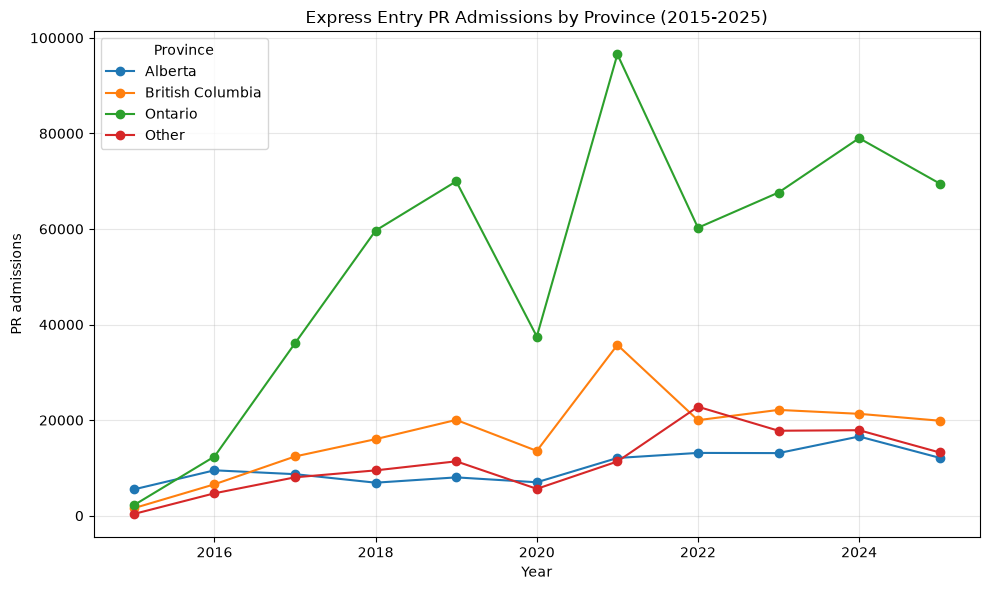

In [15]:
prov_wide.loc[2015:2025].plot(kind='line',marker='o',figsize=(10,6))
plt.title("Express Entry PR Admissions by Province (2015-2025)")
plt.xlabel("Year")
plt.ylabel("PR admissions")
plt.legend(title="Province")
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Top source countries (2015–2025)

Where Express Entry immigrants come from, and how the mix shifted over time.


In [16]:
pr_citz = pd.read_csv("../data/processed/pr_admissions_by_citizenship_cleaned.csv")
pr_citz.groupby("EN_COUNTRY_OF_CITIZENSHIP")["TOTAL"].sum().sort_values(ascending=False).head(15)

EN_COUNTRY_OF_CITIZENSHIP
India                                      456960.0
Nigeria                                     76065.0
China, People's Republic of                 55235.0
Cameroon, Federal Republic of               33270.0
United States of America                    28905.0
Pakistan                                    28700.0
Philippines                                 28670.0
Brazil                                      22585.0
United Kingdom and Overseas Territories     22240.0
Iran                                        15740.0
France                                      13875.0
Korea, Republic of                          13810.0
Morocco                                     13620.0
Algeria                                     12270.0
Ireland, Republic of                         9930.0
Name: TOTAL, dtype: float64

In [17]:
top_countries = pr_citz.groupby("EN_COUNTRY_OF_CITIZENSHIP")["TOTAL"].sum().nlargest(6).index.tolist()
print("Top 6:", top_countries)

pr_citz["country_group"] = pr_citz["EN_COUNTRY_OF_CITIZENSHIP"].where(
    pr_citz["EN_COUNTRY_OF_CITIZENSHIP"].isin(top_countries), "Other")

citz_trend = pr_citz[pr_citz["EN_YEAR"] <= 2025].groupby(
    ["EN_YEAR", "country_group"])["TOTAL"].sum().reset_index()
citz_wide = citz_trend.pivot(index="EN_YEAR", columns="country_group", values="TOTAL")
citz_wide



Top 6: ['India', 'Nigeria', "China, People's Republic of", 'Cameroon, Federal Republic of', 'United States of America', 'Pakistan']


country_group,"Cameroon, Federal Republic of","China, People's Republic of",India,Nigeria,Other,Pakistan,United States of America
EN_YEAR,,,,,,,
2015,0.0,305.0,1800.0,55.0,5775.0,80.0,335.0
2016,0.0,2590.0,9510.0,950.0,14480.0,780.0,1160.0
2017,35.0,5680.0,26315.0,2810.0,21805.0,1475.0,2760.0
2018,160.0,5815.0,39620.0,6625.0,28300.0,3465.0,3510.0
2019,415.0,5685.0,50840.0,8395.0,30775.0,4655.0,3855.0
2020,295.0,4270.0,27600.0,3865.0,19015.0,2250.0,2290.0
2021,155.0,11660.0,82915.0,5765.0,44185.0,1590.0,4215.0
2022,2310.0,4360.0,53705.0,13755.0,30350.0,3985.0,2740.0
2023,3920.0,5070.0,54045.0,9175.0,35790.0,3620.0,3340.0


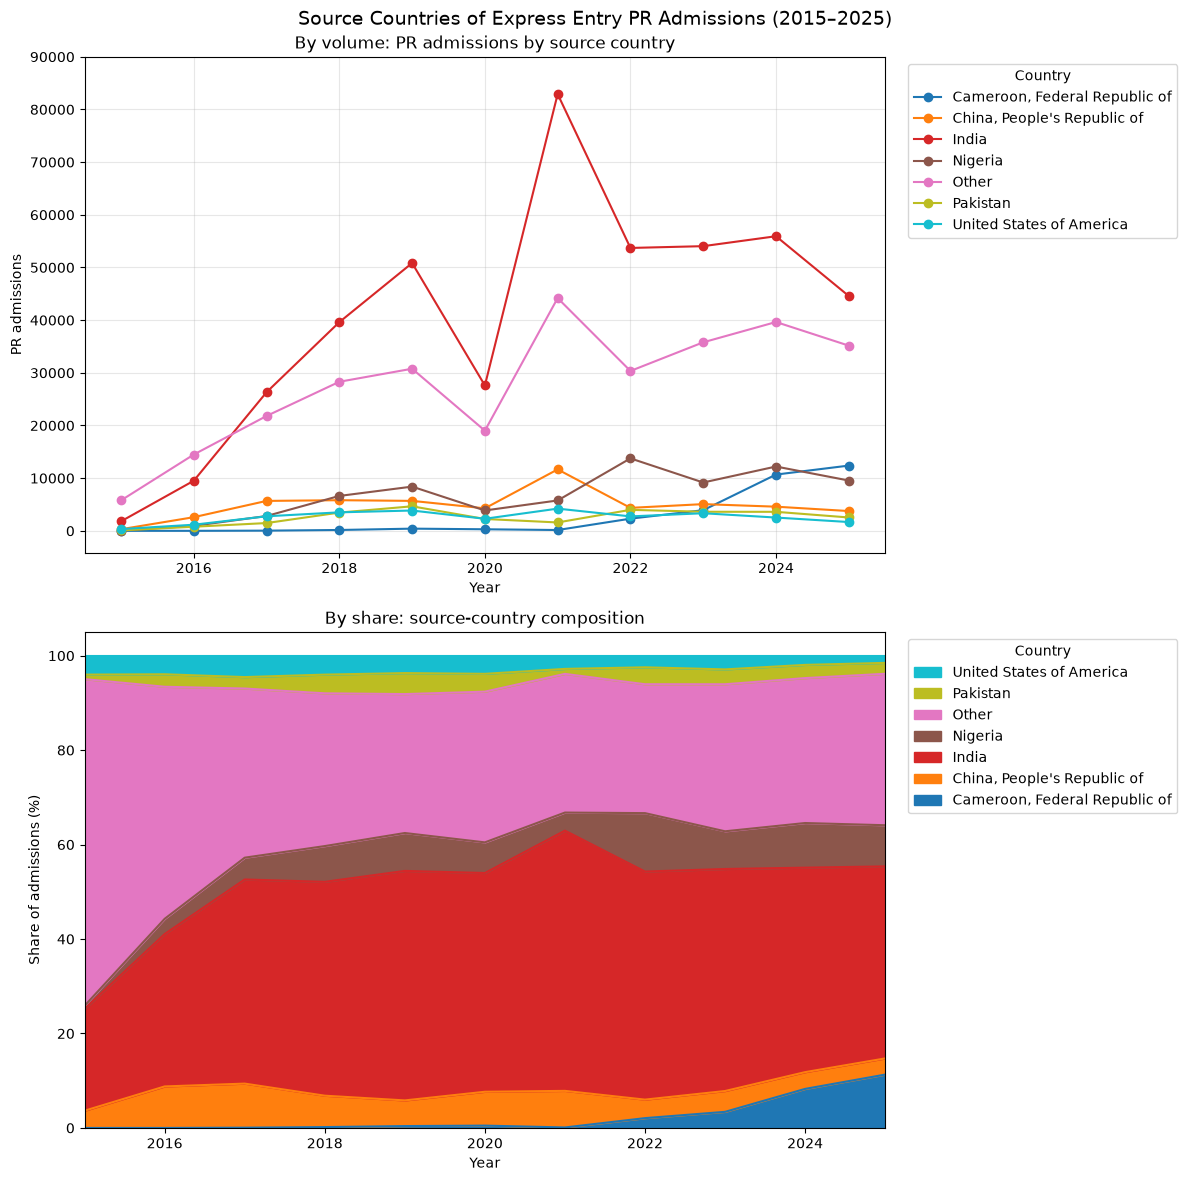

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# 上图：折线（绝对量）
citz_wide.plot(kind="line", marker="o", colormap="tab10", ax=ax1)
ax1.set_title("By volume: PR admissions by source country")
ax1.set_xlabel("Year")
ax1.set_ylabel("PR admissions")
ax1.set_yticks(range(0, 90001, 10000))
ax1.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
ax1.grid(True, alpha=0.3)

# 下图：面积（占比结构）
citz_pct = citz_wide.div(citz_wide.sum(axis=1), axis=0) * 100
citz_pct.plot(kind="area", stacked=True, colormap="tab10", ax=ax2)
ax2.set_title("By share: source-country composition")
ax2.set_xlabel("Year")
ax2.set_ylabel("Share of admissions (%)")
ax2.margins(x=0)
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles[::-1], labels[::-1], title="Country",
           bbox_to_anchor=(1.02, 1), loc="upper left")

fig.suptitle("Source Countries of Express Entry PR Admissions (2015–2025)", fontsize=14)
plt.tight_layout()
plt.show()


## 5. Income trajectory by category (years since landing)

Median employment income of EE economic-class principal applicants (CEC / skilled worker–trades / PNP), by years since landing. Cohorts 2015–2020

**Finding:** Skilled-worker/trades applicants earn the most and grow steadily (~$49k → $60k),
while Canadian Experience Class peaks earlier and plateaus lower — challenging the reform's
assumption that Canadian-experience factors best select high earners.

**Limitations:** income reaches only the 2020 cohort (data ends at tax year 2023); the year 3–4
dip reflects the 2020–2021 pandemic tax years, not a true decline.


In [20]:
income = pd.read_csv("../data/processed/statcan_immigrant_income_by_cohort.csv")
income["years_since_landing"] = income["tax_year"] - income["admission_cohort_year"]
income.head()


,admission_cohort_year,immigrant_category,statistic,tax_year,value,years_since_landing
0,2015,Canadian experience class,Median employment income,2016,29100.0,1
1,2015,Canadian experience class,Median employment income,2017,33200.0,2
2,2015,Canadian experience class,Median employment income,2018,36500.0,3
3,2015,Canadian experience class,Median employment income,2019,38900.0,4
4,2015,Canadian experience class,Median employment income,2020,43500.0,5


In [27]:
# EE 三大类别（主申请人）的就业收入轨迹
ee_cats = ["Canadian experience class", "Skilled worker/trades", "Provincial nominee"]

emp = income[(income["statistic"] == "Median employment income") &
             (income["immigrant_category"].isin(ee_cats))]

income_track = emp.groupby(["immigrant_category", "years_since_landing"])["value"].mean().reset_index()
income_track_wide = income_track.pivot(index="years_since_landing",
                                       columns="immigrant_category", values="value").loc[1:5]

income_track_wide

immigrant_category,Canadian experience class,Provincial nominee,Skilled worker/trades
years_since_landing,,,
1,46266.666667,43983.333333,48900.000000
2,50733.333333,50050.000000,54800.000000
3,56116.666667,53266.666667,60200.000000
4,53860.000000,57720.000000,60025.000000
5,50950.000000,53575.000000,60433.333333


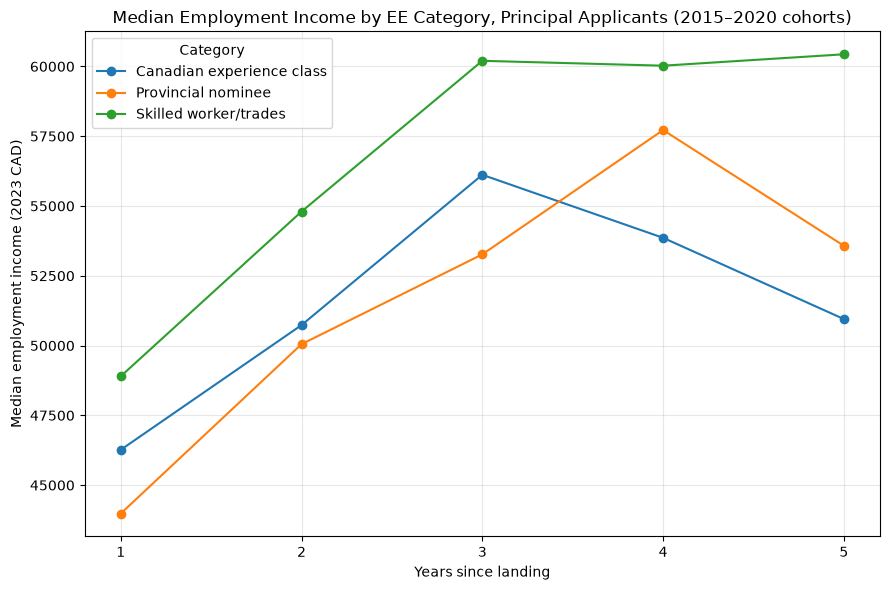

In [28]:

income_track_wide.plot(kind="line", marker="o", figsize=(9, 6))
plt.title("Median Employment Income by EE Category, Principal Applicants (2015–2020 cohorts)")
plt.xlabel("Years since landing")
plt.ylabel("Median employment income (2023 CAD)")
plt.xticks(range(1, 6))
plt.legend(title="Category")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
